In [ ]:
Machine Learning
Dataset: Adult (Census Income)
url: https://archive.ics.uci.edu/ml/datasets/adult
About the program: The program predicts whether income exceeds $50K, which makes it ideal for logistic
regression, decision trees classifiers, random forest, and gradient boosting.
Platform: Google Colab
Concepts covered:
Logistic Regression: a strong baseline for binary classification.
Decision Tree: easy to interpret and useful for non-linear splits.
Random Forest: usually stronger than a single tree because it averages many trees.
Gradient Boosting: often performs well on tabular data by building trees sequentially.

In [2]:
# Install dependencies and libraries
!pip -q install pyspark

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow import keras

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder as SparkOneHotEncoder
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

print ("libraries ready")

libraries ready


In [13]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
print("figure sizes set")

figure sizes set


In [4]:
# Load dataset and print it's shape
# =========================
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "target"
]

df = pd.read_csv(
    dataset_url,
    header=None,
    names=column_names,
    na_values="?",
    skipinitialspace=True
)

print("Dataset URL:", dataset_url)
print("Shape:", df.shape)
print("\nFirst rows:")
display(df.head())


Dataset URL: https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Shape: (32561, 15)

First rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# 4) Standard analysis
# =========================
print("\n--- Numerical summary ---")
display(df.describe(include=[np.number]).T)

print("\n--- Categorical summary ---")
display(df.describe(include=["object"]).T)

print("\n--- Missing values ---")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\n--- Target distribution ---")
display(df["target"].value_counts(normalize=True).rename("proportion"))



--- Numerical summary ---


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0



--- Categorical summary ---


,count,unique,top,freq
workclass,30725,8,Private,22696
education,32561,16,HS-grad,10501
marital-status,32561,7,Married-civ-spouse,14976
occupation,30718,14,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native-country,31978,41,United-States,29170
target,32561,2,<=50K,24720



--- Missing values ---


,0
occupation,1843
workclass,1836
native-country,583



--- Target distribution ---


,proportion
target,
<=50K,0.75919
>50K,0.24081


/tmp/ipykernel_708/1459268176.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", palette="Set2")


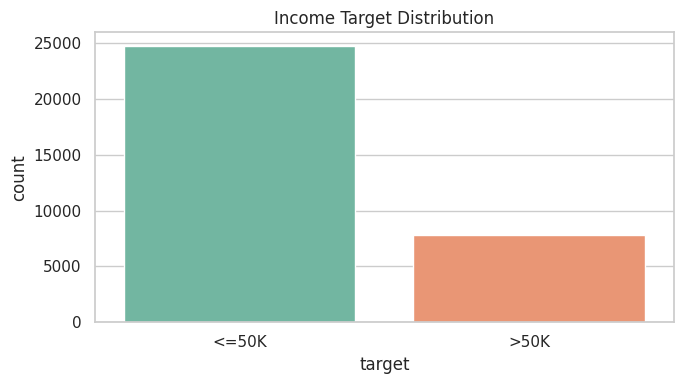

In [14]:
# Visualizations: countplot

plt.figure()
sns.countplot(data=df, x="target", palette="Set2")
plt.title("Income Target Distribution")
plt.tight_layout()
plt.show()


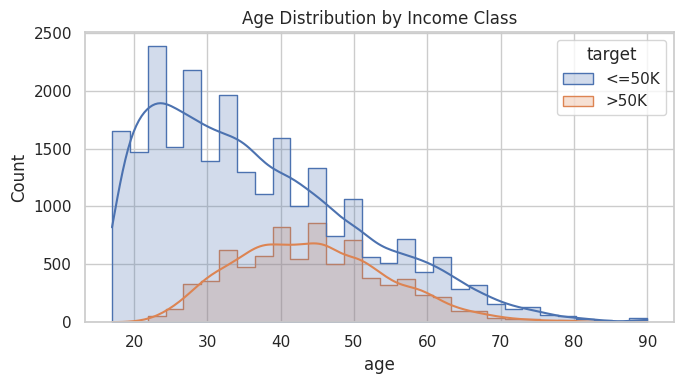

In [15]:
# Visualizations: histogram
plt.figure()
sns.histplot(data=df, x="age", hue="target", bins=30, kde=True, element="step")
plt.title("Age Distribution by Income Class")
plt.tight_layout()
plt.show()


/tmp/ipykernel_708/2101708936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y="hours-per-week", palette="Set3")


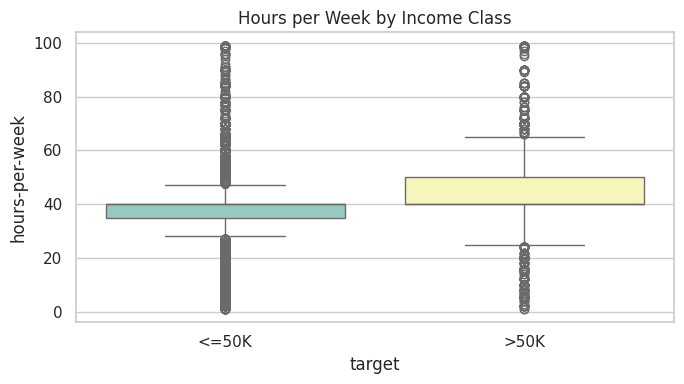

In [16]:
# Visualization: boxplot
plt.figure()
sns.boxplot(data=df, x="target", y="hours-per-week", palette="Set3")
plt.title("Hours per Week by Income Class")
plt.tight_layout()
plt.show()


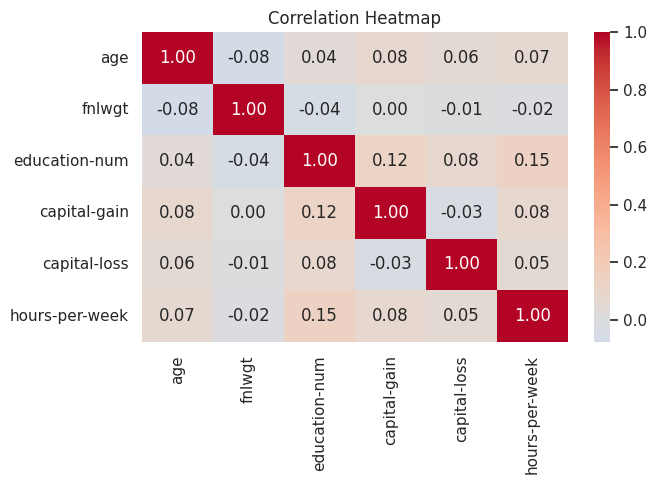

In [26]:
# Visualization: heatmap
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


/tmp/ipykernel_708/3584759372.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


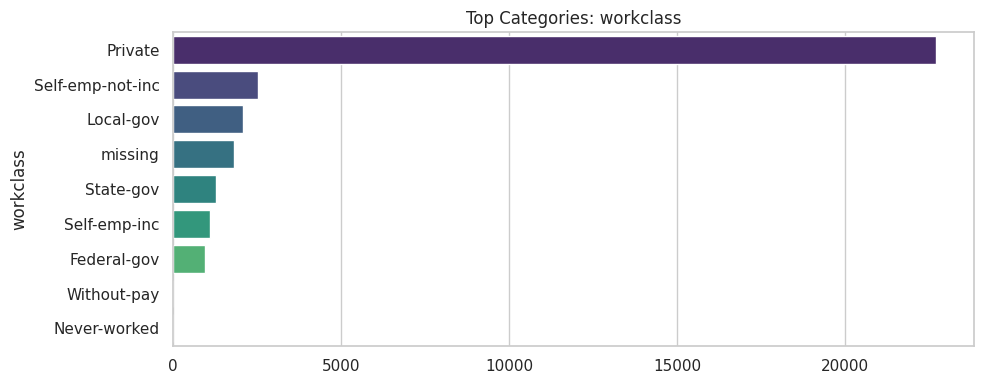

/tmp/ipykernel_708/3584759372.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


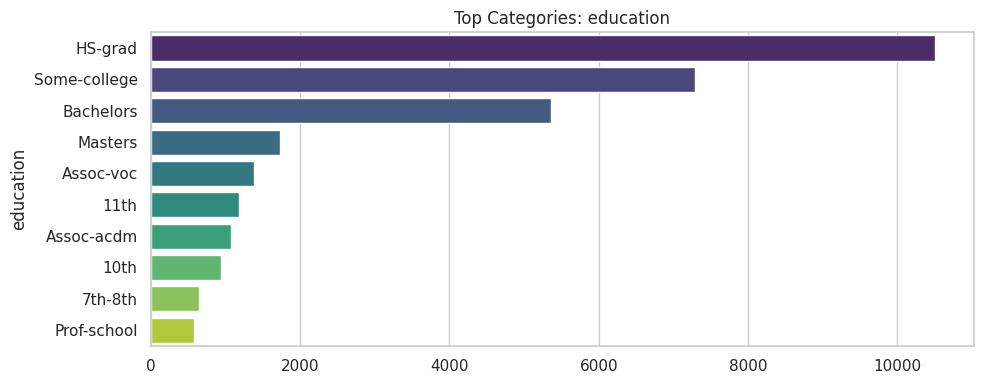

/tmp/ipykernel_708/3584759372.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


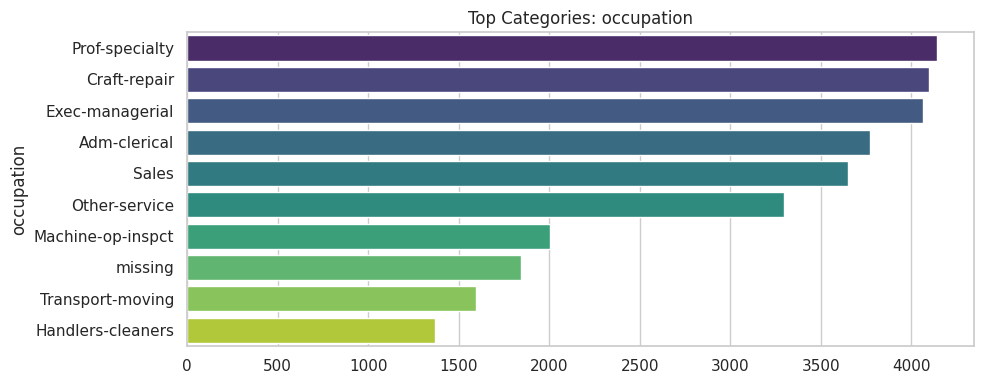

/tmp/ipykernel_708/3584759372.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


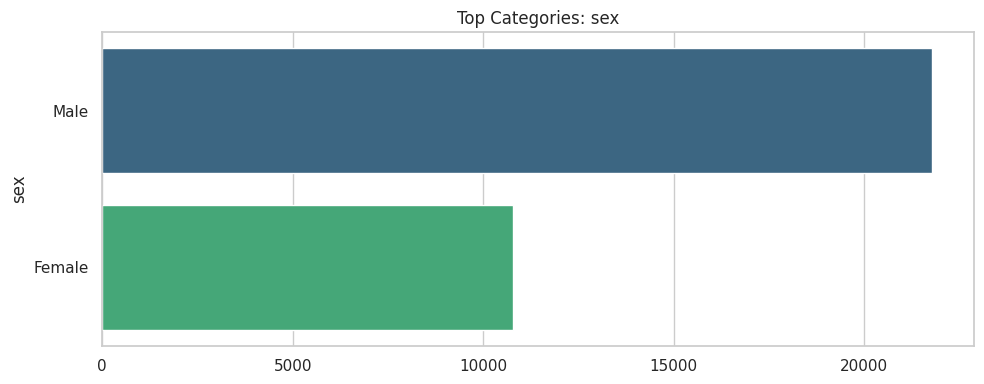

In [28]:
# Visualization: barplot
for c in ["workclass", "education", "occupation", "sex"]:
    plt.figure(figsize=(10, 4))
    top = df[c].fillna("missing").value_counts().head(10)
    sns.barplot(x=top.values, y=top.index, palette="viridis")
    plt.title(f"Top Categories: {c}")
    plt.tight_layout()
    plt.show()


In [29]:
# ML prep

target_encoder = LabelEncoder()
y_enc = target_encoder.fit_transform(df["target"].astype(str))

X_ml = df.drop(columns=["target"])
categorical_cols = X_ml.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_ml.select_dtypes(exclude=["object", "category"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf.named_steps["model"], "predict_proba") else None

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba) if proba is not None else np.nan
    results.append({"model": name, "accuracy": acc, "auc": auc})

    print("\n" + "="*50)
    print(name)
    print("Accuracy:", round(acc, 4), "AUC:", round(auc, 4) if pd.notna(auc) else "NA")
    print(classification_report(y_test, pred, target_names=target_encoder.classes_))



Logistic Regression
Accuracy: 0.8558 AUC: 0.9078
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513


Decision Tree
Accuracy: 0.8104 AUC: 0.7525
              precision    recall  f1-score   support

       <=50K       0.88      0.86      0.87      4945
        >50K       0.60      0.64      0.62      1568

    accuracy                           0.81      6513
   macro avg       0.74      0.75      0.75      6513
weighted avg       0.82      0.81      0.81      6513


Random Forest
Accuracy: 0.858 AUC: 0.9082
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.74      0.64      0.68      1568

    accuracy                           0.86  

In [12]:
# Accuracy
results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
display(results_df)

,model,accuracy,auc
3,Gradient Boosting,0.868878,0.923389
2,Random Forest,0.857976,0.908239
0,Logistic Regression,0.855827,0.907801
1,Decision Tree,0.810379,0.752525


/tmp/ipykernel_708/2080380285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="accuracy", y="model", palette="mako")


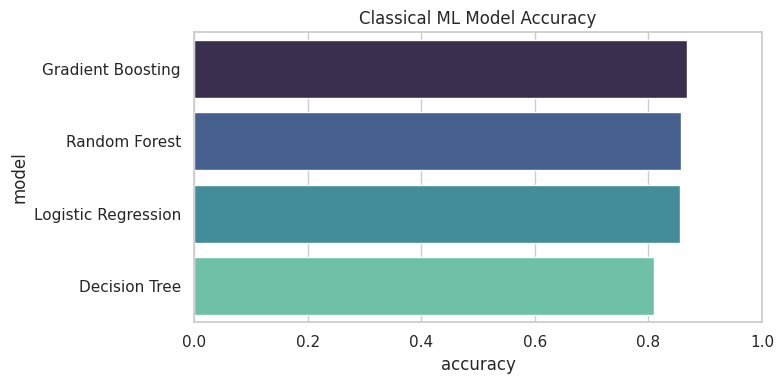

In [30]:
# Visualization: barplot
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="accuracy", y="model", palette="mako")
plt.title("Classical ML Model Accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


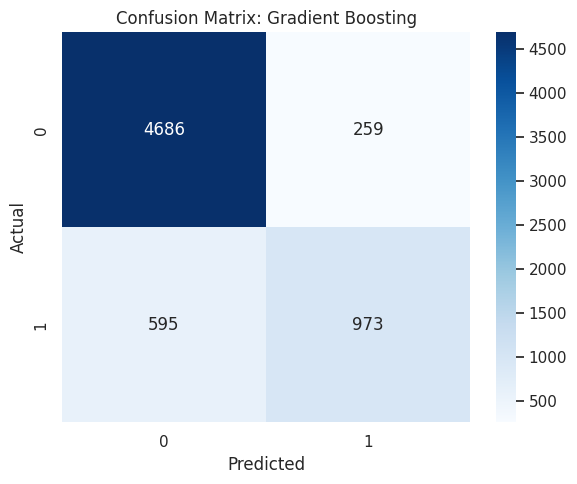

In [31]:
# Visualization: heatmap
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", best_model)])
best_clf.fit(X_train, y_train)
best_pred = best_clf.predict(X_test)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Epoch 1/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8377 - loss: 0.3472 - val_accuracy: 0.8459 - val_loss: 0.3274
Epoch 2/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8529 - loss: 0.3148 - val_accuracy: 0.8488 - val_loss: 0.3228
Epoch 3/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8563 - loss: 0.3106 - val_accuracy: 0.8488 - val_loss: 0.3225
Epoch 4/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8584 - loss: 0.3055 - val_accuracy: 0.8484 - val_loss: 0.3237
Epoch 5/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8623 - loss: 0.3031 - val_accuracy: 0.8522 - val_loss: 0.3206
Epoch 6/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8627 - loss: 0.3001 - val_accuracy: 0.8524 - val_loss: 0.3205
Epoch 7/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8625 - loss: 0.2993 - val_accuracy: 0.8514 - val_loss: 0.3217
Epoch 8/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8641 - loss: 0.2967 - val_accuracy: 0.

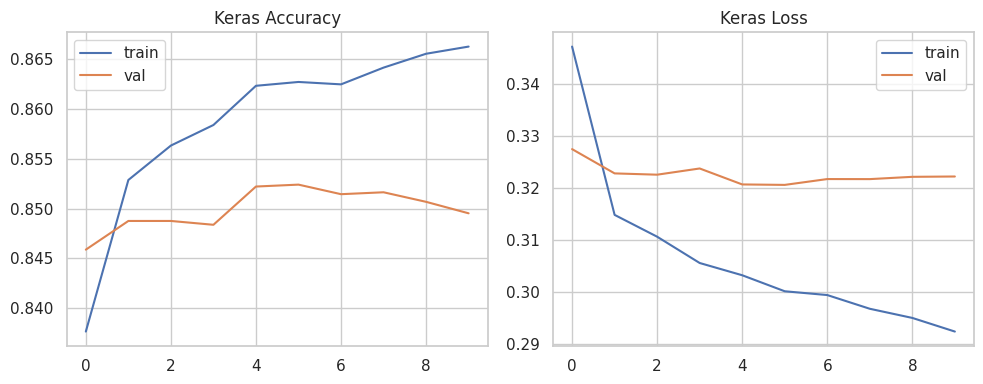

In [22]:
# TensorFlow / Keras

X_train_tf = preprocessor.fit_transform(X_train)
X_test_tf = preprocessor.transform(X_test)

if hasattr(X_train_tf, "toarray"):
    X_train_tf = X_train_tf.toarray()
    X_test_tf = X_test_tf.toarray()

tf_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_tf.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

tf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = tf_model.fit(
    X_train_tf, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

tf_loss, tf_acc = tf_model.evaluate(X_test_tf, y_test, verbose=0)
print("\nTensorFlow/Keras test accuracy:", round(tf_acc, 4))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Keras Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Keras Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import trim, col, when
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder as SparkOneHotEncoder
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

spark = SparkSession.builder.master("local[*]").appName("AdultIncome").getOrCreate()

spark_df = spark.createDataFrame(df)

# Clean target and force exactly two classes
spark_df = spark_df.withColumn("target", trim(col("target")))
spark_df = spark_df.withColumn(
    "label",
    when(col("target").isin(">50K", ">50K."), 1.0)
    .when(col("target").isin("<=50K", "<=50K."), 0.0)
    .otherwise(None)
)
spark_df = spark_df.filter(col("label").isNotNull())

# Fill missing values
for c in numeric_cols:
    spark_df = spark_df.na.fill({c: 0})

for c in categorical_cols:
    spark_df = spark_df.na.fill({c: "missing"})

# Feature encoding
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    SparkOneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_oh"])
    for c in categorical_cols
]

assembler = VectorAssembler(
    inputCols=numeric_cols + [f"{c}_oh" for c in categorical_cols],
    outputCol="features"
)

spark_lr = SparkLogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="binomial"
)

spark_pipeline = SparkPipeline(stages=indexers + encoders + [assembler, spark_lr])

train_spark, test_spark = spark_df.randomSplit([0.8, 0.2], seed=42)
spark_model = spark_pipeline.fit(train_spark)
spark_preds = spark_model.transform(test_spark)

# Accuracy
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
acc = evaluator_acc.evaluate(spark_preds)

# AUC
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = evaluator_auc.evaluate(spark_preds)

print("PySpark Logistic Regression Accuracy:", round(acc, 4))
print("PySpark Logistic Regression AUC:", round(auc, 4))

PySpark Logistic Regression Accuracy: 0.8552
PySpark Logistic Regression AUC: 0.9061
